In [1]:
# import cuml.accel
# cuml.accel.install()  # Must be called before other imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

%matplotlib inline

In [2]:
df_2020 = pd.read_csv('data/delta_table_2020_3x3.csv')
df_2021 = pd.read_csv('data/delta_table_2021_3x3.csv')

df_2021 = df_2021[df_2021['delta_years'] != 5]

In [3]:
df_2020.shape, df_2021.shape

((2286815, 95), (2286815, 95))

In [4]:
df_2020.columns

Index(['delta_years', 'system:index', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5',
       'B6', 'B7', 'B8', 'bare_sparse_vegetation', 'built_up', 'cropland',
       'grassland', 'image_count', 'tree_cover', 'water', 'x', 'y', 'year',
       '.geo', 'geometry', 'B11_m1_m1', 'B12_m1_m1', 'B2_m1_m1', 'B3_m1_m1',
       'B4_m1_m1', 'B5_m1_m1', 'B6_m1_m1', 'B7_m1_m1', 'B8_m1_m1', 'B11_p0_m1',
       'B12_p0_m1', 'B2_p0_m1', 'B3_p0_m1', 'B4_p0_m1', 'B5_p0_m1', 'B6_p0_m1',
       'B7_p0_m1', 'B8_p0_m1', 'B11_p1_m1', 'B12_p1_m1', 'B2_p1_m1',
       'B3_p1_m1', 'B4_p1_m1', 'B5_p1_m1', 'B6_p1_m1', 'B7_p1_m1', 'B8_p1_m1',
       'B11_m1_p0', 'B12_m1_p0', 'B2_m1_p0', 'B3_m1_p0', 'B4_m1_p0',
       'B5_m1_p0', 'B6_m1_p0', 'B7_m1_p0', 'B8_m1_p0', 'B11_p1_p0',
       'B12_p1_p0', 'B2_p1_p0', 'B3_p1_p0', 'B4_p1_p0', 'B5_p1_p0', 'B6_p1_p0',
       'B7_p1_p0', 'B8_p1_p0', 'B11_m1_p1', 'B12_m1_p1', 'B2_m1_p1',
       'B3_m1_p1', 'B4_m1_p1', 'B5_m1_p1', 'B6_m1_p1', 'B7_m1_p1', 'B8_m1_p1',
       'B11_p0_p1', 'B1

In [5]:
df_2020 = df_2020.drop(columns=['year', "system:index", "image_count", ".geo", "geometry", "x", "y"])
df_2020 = df_2020.fillna(df_2020.mean())

df_2021 = df_2021.drop(columns=['year', "system:index", "image_count", ".geo", "geometry", "x", "y"])
df_2021 = df_2021.fillna(df_2021.mean())

In [6]:
df_2020['vegetation'] = df_2020[['tree_cover', 'cropland', 'grassland']].sum(axis=1)
df_2021['vegetation'] = df_2021[['tree_cover', 'cropland', 'grassland']].sum(axis=1)

target_labels = [
    'built_up',
    'vegetation',
    'water'
]

remaining_target = [
    'bare_sparse_vegetation',
    'tree_cover',
    'grassland',
    'cropland'
]


In [7]:
df_2020.columns

Index(['delta_years', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'bare_sparse_vegetation', 'built_up', 'cropland', 'grassland',
       'tree_cover', 'water', 'B11_m1_m1', 'B12_m1_m1', 'B2_m1_m1', 'B3_m1_m1',
       'B4_m1_m1', 'B5_m1_m1', 'B6_m1_m1', 'B7_m1_m1', 'B8_m1_m1', 'B11_p0_m1',
       'B12_p0_m1', 'B2_p0_m1', 'B3_p0_m1', 'B4_p0_m1', 'B5_p0_m1', 'B6_p0_m1',
       'B7_p0_m1', 'B8_p0_m1', 'B11_p1_m1', 'B12_p1_m1', 'B2_p1_m1',
       'B3_p1_m1', 'B4_p1_m1', 'B5_p1_m1', 'B6_p1_m1', 'B7_p1_m1', 'B8_p1_m1',
       'B11_m1_p0', 'B12_m1_p0', 'B2_m1_p0', 'B3_m1_p0', 'B4_m1_p0',
       'B5_m1_p0', 'B6_m1_p0', 'B7_m1_p0', 'B8_m1_p0', 'B11_p1_p0',
       'B12_p1_p0', 'B2_p1_p0', 'B3_p1_p0', 'B4_p1_p0', 'B5_p1_p0', 'B6_p1_p0',
       'B7_p1_p0', 'B8_p1_p0', 'B11_m1_p1', 'B12_m1_p1', 'B2_m1_p1',
       'B3_m1_p1', 'B4_m1_p1', 'B5_m1_p1', 'B6_m1_p1', 'B7_m1_p1', 'B8_m1_p1',
       'B11_p0_p1', 'B12_p0_p1', 'B2_p0_p1', 'B3_p0_p1', 'B4_p0_p1',
       'B5_p0_p1', 'B6_p0_p1',

In [8]:
# --- Feature Engineering for df_2020 ---
# Vegetation Indices
df_2020['NDVI'] = (df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + df_2020['B4'] + 1e-8)
# df_2020['EVI'] = 2.5 * ((df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + 6 * df_2020['B4'] - 7.5 * df_2020['B2'] + 1 + 1e-8))
df_2020['EVI2'] = 2.5 * ((df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + 2.4 * df_2020['B4'] + 1 + 1e-8))
df_2020['SAVI'] = ((df_2020['B8'] - df_2020['B4']) * 1.5) / (df_2020['B8'] + df_2020['B4'] + 0.5 + 1e-8)
# df_2020['NDRE'] = (df_2020['B8'] - df_2020['B5']) / (df_2020['B8'] + df_2020['B5'] + 1e-8)
# df_2020['GNDVI'] = (df_2020['B8'] - df_2020['B3']) / (df_2020['B8'] + df_2020['B3'] + 1e-8)

# Urban & Built-up Indices
df_2020['NDBI'] = (df_2020['B11'] - df_2020['B8']) / (df_2020['B11'] + df_2020['B8'] + 1e-8)

# Water & Moisture Indices
df_2020['NDWI'] = (df_2020['B3'] - df_2020['B8']) / (df_2020['B3'] + df_2020['B8'] + 1e-8)
df_2020['MNDWI'] = (df_2020['B3'] - df_2020['B11']) / (df_2020['B3'] + df_2020['B11'] + 1e-8)


# --- Feature Engineering for df_2021 ---
# Vegetation Indices
df_2021['NDVI'] = (df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + df_2021['B4'] + 1e-8)
# df_2021['EVI'] = 2.5 * ((df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + 6 * df_2021['B4'] - 7.5 * df_2021['B2'] + 1 + 1e-8))
df_2021['EVI2'] = 2.5 * ((df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + 2.4 * df_2021['B4'] + 1 + 1e-8))
df_2021['SAVI'] = ((df_2021['B8'] - df_2021['B4']) * 1.5) / (df_2021['B8'] + df_2021['B4'] + 0.5 + 1e-8)
# df_2021['NDRE'] = (df_2021['B8'] - df_2021['B5']) / (df_2021['B8'] + df_2021['B5'] + 1e-8)
# df_2021['GNDVI'] = (df_2021['B8'] - df_2021['B3']) / (df_2021['B8'] + df_2021['B3'] + 1e-8)

# Urban & Built-up Indices
df_2021['NDBI'] = (df_2021['B11'] - df_2021['B8']) / (df_2021['B11'] + df_2021['B8'] + 1e-8)

# Water & Moisture Indices
df_2021['NDWI'] = (df_2021['B3'] - df_2021['B8']) / (df_2021['B3'] + df_2021['B8'] + 1e-8)
df_2021['MNDWI'] = (df_2021['B3'] - df_2021['B11']) / (df_2021['B3'] + df_2021['B11'] + 1e-8)

In [9]:
X_train = df_2020.drop(columns=target_labels + remaining_target)
X_train = X_train.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
y_train = df_2020[target_labels]

X_test = df_2021.drop(columns=target_labels + remaining_target)
X_test = X_test.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
y_test = df_2021[target_labels]

In [10]:
X_train.columns, y_train.columns

(Index(['delta_years', 'B11', 'B12', 'B2', 'B3', 'B5', 'B6', 'B11_m1_m1',
        'B12_m1_m1', 'B2_m1_m1', 'B3_m1_m1', 'B4_m1_m1', 'B5_m1_m1', 'B6_m1_m1',
        'B7_m1_m1', 'B8_m1_m1', 'B11_p0_m1', 'B12_p0_m1', 'B2_p0_m1',
        'B3_p0_m1', 'B4_p0_m1', 'B5_p0_m1', 'B6_p0_m1', 'B7_p0_m1', 'B8_p0_m1',
        'B11_p1_m1', 'B12_p1_m1', 'B2_p1_m1', 'B3_p1_m1', 'B4_p1_m1',
        'B5_p1_m1', 'B6_p1_m1', 'B7_p1_m1', 'B8_p1_m1', 'B11_m1_p0',
        'B12_m1_p0', 'B2_m1_p0', 'B3_m1_p0', 'B4_m1_p0', 'B5_m1_p0', 'B6_m1_p0',
        'B7_m1_p0', 'B8_m1_p0', 'B11_p1_p0', 'B12_p1_p0', 'B2_p1_p0',
        'B3_p1_p0', 'B4_p1_p0', 'B5_p1_p0', 'B6_p1_p0', 'B7_p1_p0', 'B8_p1_p0',
        'B11_m1_p1', 'B12_m1_p1', 'B2_m1_p1', 'B3_m1_p1', 'B4_m1_p1',
        'B5_m1_p1', 'B6_m1_p1', 'B7_m1_p1', 'B8_m1_p1', 'B11_p0_p1',
        'B12_p0_p1', 'B2_p0_p1', 'B3_p0_p1', 'B4_p0_p1', 'B5_p0_p1', 'B6_p0_p1',
        'B7_p0_p1', 'B8_p0_p1', 'B11_p1_p1', 'B12_p1_p1', 'B2_p1_p1',
        'B3_p1_p1', 'B4_p1_p1', 'B5

In [11]:
import xgboost as xgb

def _predict_multioutput_xgb_with_dmatrix(model, X):
    dX = xgb.DMatrix(X)
    preds = [est.get_booster().predict(dX) for est in model.estimators_]
    return np.column_stack(preds)

def evaluate_regression_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    if (
        isinstance(model, MultiOutputRegressor)
        and isinstance(model.estimator, XGBRegressor)
    ):
        y_train_pred = _predict_multioutput_xgb_with_dmatrix(model, X_train)
        y_test_pred = _predict_multioutput_xgb_with_dmatrix(model, X_test)
    else:
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

    train_rmse = root_mean_squared_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    test_rmse = root_mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"--- {model_name} ---")
    print(f"Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")
    print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}\n")

    return {
        'Model': model_name,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2
    }

In [12]:
from sklearn.ensemble import StackingRegressor

base_learners = [
    ('xgb', XGBRegressor(
        n_estimators=789,
        learning_rate=0.03970073695782001,
        random_state=42,
        max_depth=15,
        gamma=1.0391440954448874,
        min_child_weight=13,
        reg_alpha=2.5063145700217895,
        reg_lambda=1.3677301006351343,
        colsample_bytree=0.6174545647503418,
        subsample=0.8900211377979158,
        device='cuda',
        n_jobs=-1
    )),
    ('rf', RandomForestRegressor(
        n_estimators=390,
        random_state=42,
        max_depth=9,
        min_samples_split=14,
        min_samples_leaf=8,
        max_features=0.6061272316154472,
        n_jobs=-1
    )),
    ('knn', Pipeline([
        ('scaler', StandardScaler()),
        ('knn_reg', KNeighborsRegressor(
            n_neighbors=28, 
            weights='uniform', 
            metric='minkowski', 
            p=2, 
            leaf_size=24,
            n_jobs=-1
        ))
    ]))
]

meta_learner = LinearRegression()

stacking_model = MultiOutputRegressor(
    StackingRegressor(
        estimators=base_learners,
        final_estimator=meta_learner,
        cv=2,
        n_jobs=-1
    )
)

stacking_model

,estimator,"StackingRegre...(), n_jobs=-1)"
,n_jobs,None
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6174545647503418
,device,'cuda'
,early_stopping_rounds,None


In [13]:
results = []
res = evaluate_regression_model("Stacking Regressor", stacking_model, X_train, X_test, y_train, y_test)
results.append(res)

[02:44:58] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

[05:00:49] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

[07:21:02] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to p

--- Stacking Regressor ---
Train R2: 0.9151 | Test R2: 0.8882
Train RMSE: 0.1016 | Test RMSE: 0.1184



In [14]:
summary_df = pd.DataFrame(results).sort_values(by='Test RMSE', ascending=True)
display(summary_df)

,Model,Train RMSE,Test RMSE,Train R2,Test R2
0,Stacking Regressor,0.101648,0.11844,0.915089,0.888201


In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

current_labels = [
    'built_up',
    'vegetation',
    'water'
]

y_pred_array = stacking_model.predict(X_test)

y_pred_df = pd.DataFrame(y_pred_array, columns=current_labels)

true_dominant = y_test[current_labels].idxmax(axis=1).reset_index(drop=True)
pred_dominant = y_pred_df.idxmax(axis=1)

comparison_df = pd.DataFrame({
    'True_Dominant_Class': true_dominant,
    'Pred_Dominant_Class': pred_dominant
})
comparison_df['Match'] = comparison_df['True_Dominant_Class'] == comparison_df['Pred_Dominant_Class']

display(comparison_df.head(5))

,True_Dominant_Class,Pred_Dominant_Class,Match
0,built_up,built_up,True
1,built_up,built_up,True
2,built_up,built_up,True
3,built_up,built_up,True
4,built_up,built_up,True


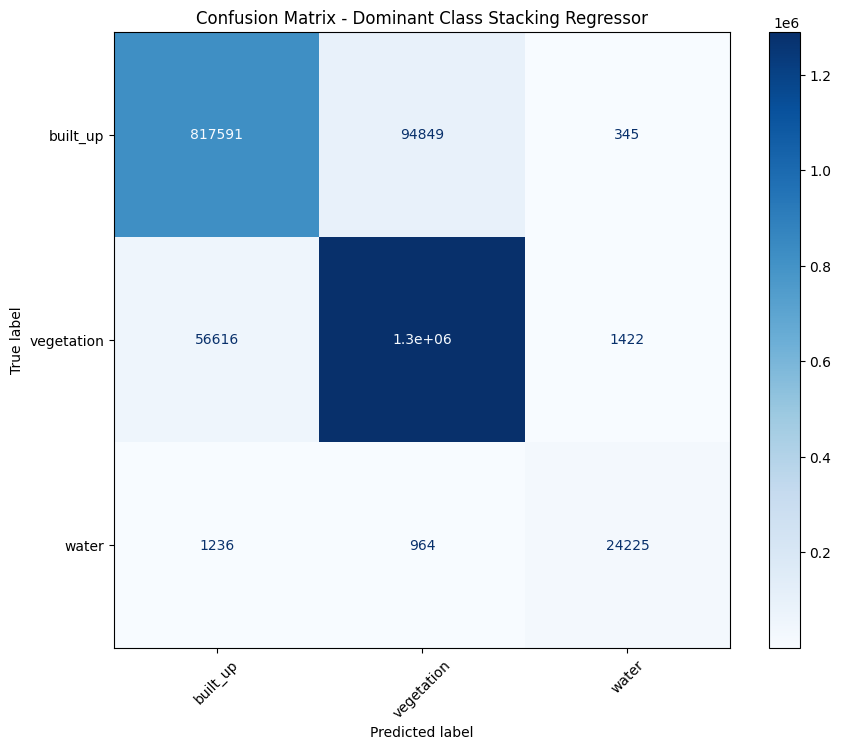

In [16]:
cm = confusion_matrix(true_dominant, pred_dominant, labels=current_labels)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=current_labels)
disp.plot(cmap='Blues', xticks_rotation=45, ax=plt.gca())
plt.title(f'Confusion Matrix - Dominant Class Stacking Regressor')
plt.show()

In [17]:
accuracy = comparison_df['Match'].mean()
print(f"Overall Dominant Class Accuracy: {accuracy:.4f}")

Overall Dominant Class Accuracy: 0.9320


In [18]:
import pickle

model_filename = 'models/stacking_delta.pkl'

with open(model_filename, 'wb') as f:
    pickle.dump(stacking_model, f)

print(f"All models have been saved to {model_filename}")

All models have been saved to models/stacking_delta.pkl
